# K-Nearest Neighbors (KNN) para regresión

En este notebook veremos cómo funciona **KNN para regresión**.

La idea es muy simple:

- Para predecir un nuevo valor
- Buscamos los **K vecinos más cercanos**
- Promediamos sus valores de salida

A diferencia de otros modelos, KNN no ajusta una recta, una curva o un árbol de decisión.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

## 1. Generación de datos

Creamos datos no lineales para ver cómo KNN se adapta usando vecinos cercanos.

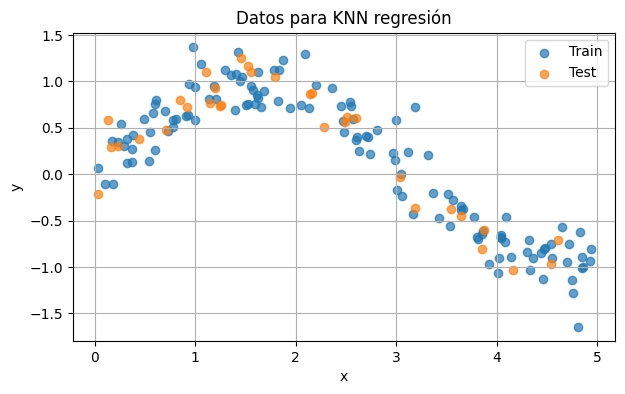

In [2]:
np.random.seed(42)

X = 5 * np.random.rand(160, 1)
y = np.sin(X[:, 0]) + 0.2 * np.random.randn(160)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

plt.figure(figsize=(7,4))
plt.scatter(X_train, y_train, alpha=0.7, label='Train')
plt.scatter(X_test, y_test, alpha=0.7, label='Test')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Datos para KNN regresión')
plt.legend()
plt.grid(True)
plt.show()

## 2. Entrenamiento del modelo

Aunque en scikit-learn usamos `fit()`, KNN no aprende coeficientes como la regresión lineal.

En la práctica:
- guarda los datos de entrenamiento
- y en el momento de predecir busca los vecinos más cercanos

In [3]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print(f"MSE: {mse:.4f}")

MSE: 0.0397


## 3. Visualización de la predicción

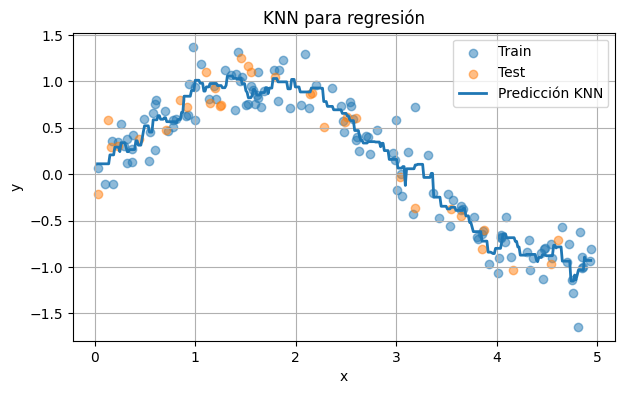

In [4]:
X_plot = np.linspace(X.min(), X.max(), 400).reshape(-1, 1)
y_plot = knn.predict(X_plot)

plt.figure(figsize=(7,4))
plt.scatter(X_train, y_train, alpha=0.5, label='Train')
plt.scatter(X_test, y_test, alpha=0.5, label='Test')
plt.plot(X_plot, y_plot, linewidth=2, label='Predicción KNN')
plt.xlabel('x')
plt.ylabel('y')
plt.title('KNN para regresión')
plt.legend()
plt.grid(True)
plt.show()

## 4. Comparación de distintos valores de K

El hiperparámetro más importante es `K`:

- K pequeño → modelo muy local y sensible al ruido
- K grande → modelo más suave y menos sensible

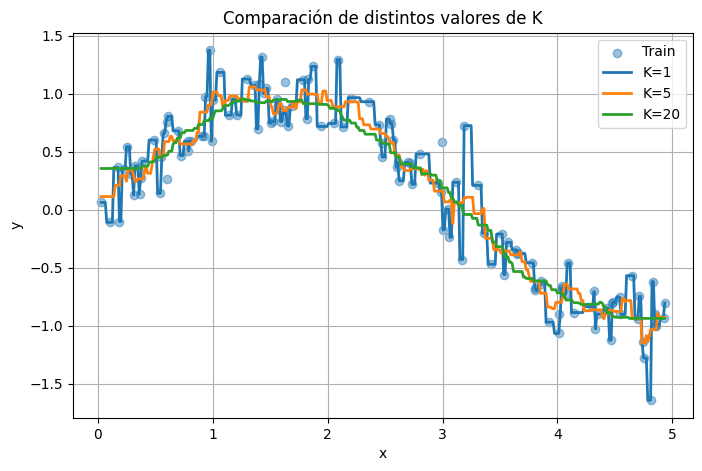

K=1 -> MSE test: 0.0900
K=5 -> MSE test: 0.0397
K=20 -> MSE test: 0.0367


In [5]:
ks = [1, 5, 20]
resultados = []

plt.figure(figsize=(8,5))
plt.scatter(X_train, y_train, alpha=0.45, label='Train')

for k in ks:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)

    y_pred_k = model.predict(X_test)
    mse_k = mean_squared_error(y_test, y_pred_k)
    resultados.append((k, mse_k))

    y_plot_k = model.predict(X_plot)
    plt.plot(X_plot, y_plot_k, linewidth=2, label=f"K={k}")

plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparación de distintos valores de K')
plt.legend()
plt.grid(True)
plt.show()

for k, mse_k in resultados:
    print(f"K={k} -> MSE test: {mse_k:.4f}")

## 5. Train vs Test

Esto ayuda a ver cómo cambia la flexibilidad del modelo.

In [6]:
for k in [1, 3, 5, 10, 20, 40]:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)

    print(f"K={k} -> MSE train: {mse_train:.4f} | MSE test: {mse_test:.4f}")

K=1 -> MSE train: 0.0000 | MSE test: 0.0900
K=3 -> MSE train: 0.0336 | MSE test: 0.0470
K=5 -> MSE train: 0.0370 | MSE test: 0.0397
K=10 -> MSE train: 0.0433 | MSE test: 0.0400
K=20 -> MSE train: 0.0490 | MSE test: 0.0367
K=40 -> MSE train: 0.0648 | MSE test: 0.0549


## 6. Idea importante

KNN hace predicciones **locales**.

Para cada nuevo punto:
1. calcula distancias a los datos de entrenamiento
2. selecciona los K vecinos más cercanos
3. promedia sus valores

Por eso decimos que es un modelo basado en instancia o vecinos.

## 7. Conclusiones

- KNN no aprende una fórmula explícita
- Su comportamiento depende mucho del valor de `K`
- K pequeño puede llevar a sobreajuste
- K grande puede suavizar demasiado
- La predicción depende de los puntos más cercanos

## 8. Ejercicios

1. Probar `K = 2, 10, 30`
2. Comparar visualmente `K=1` y `K=20`
3. Explicar qué significa que KNN sea un modelo local
4. Pensar por qué en KNN es importante la escala de las variables